# Reference Card Extraction

This notebook now explores the reusable extraction code in `src/uno_vision/data/reference_cards.py`.
The heavy lifting lives in the package; the cells here focus on picking inputs, running the extractor, and visualizing the generated assets.

In [170]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from uno_vision.data.reference_cards import (
    _mask_pipeline_steps,
    extract_reference_card_assets,
    load_reference_image,
    plot_crop_preview,
    plot_pipeline_steps,
)
from uno_vision.paths import REFERENCE_CARDS_DIR, REFERENCE_IMAGES_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference images: {REFERENCE_IMAGES_DIR}")
print(f"Processed outputs: {REFERENCE_CARDS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Reference images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\reference_images
Processed outputs: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards


In [171]:
# ── Image selection ──────────────────────────────────────────────────────────
# Map each reference image to its expected card count.
image_components = {
    "L1000765": 12,
    "L1000766": 12,
    "L1000767": 14,
    "L1000768": 16,
}

# None → process every entry above; or restrict to a subset, e.g. ["L1000768"]
images_to_process = None

# Which image to use for the single-image preview cells (mask viz + crop grid).
preview_image_name = "L1000765"

# ── Hyperparameters (in order of application) ────────────────────────────────
# All kernel sizes are scaled internally to the image resolution unless noted.

# ── Phase 1 · Canny edge detection + morphological mask ──────────────────────

# [Step 1] GaussianBlur — smooth the gray image to reduce noise before Canny
canny_blur_size = 20   # kernel size, scaled to image resolution

# [Step 2] Canny edge detection — find card outlines
canny_low = 15         # lower hysteresis threshold
canny_high = 25        # upper hysteresis threshold

# [Step 3] Morphological CLOSE — join broken edge fragments into solid card blobs
blob_close_size = 30   # kernel size, scaled to image resolution

# [Step 4] Median blur — final smoothing of the closed edge map → binary mask
blur_after = 10        # kernel size, scaled to image resolution

# ── Phase 2 · Component extraction + filtering ────────────────────────────────

# [Step 5] Small-contour removal — erase noise regions below the area threshold
min_area_abs = 100     # minimum component area in pixels (at 4000px reference scale)
min_area_frac = 0.002  # minimum component area as fraction of total image area

# [Step 6] Morphological CLOSE — fill card interiors after noise removal
close_size = 21        # kernel size in pixels (not scaled)

# [Step 7] Morphological OPEN — remove residual speckles left after closing
open_size = 7          # kernel size in pixels (not scaled)

# [Step 8] Aspect-ratio filter — keep only card-shaped connected components
min_ar = 0.3           # minimum bounding-box aspect ratio w/h (portrait cards ~0.65)
max_ar = 2.0           # maximum bounding-box aspect ratio w/h

pipeline_kwargs = dict(
    canny_blur_size=canny_blur_size, canny_low=canny_low, canny_high=canny_high,
    blob_close_size=blob_close_size, blur_after=blur_after,
    min_area_abs=min_area_abs, min_area_frac=min_area_frac,
    close_size=close_size, open_size=open_size, min_ar=min_ar, max_ar=max_ar,
)

In [ ]:
import numpy as np
import cv2

def _odd(value: float) -> int:
    """Return value rounded up to the nearest odd integer >= 3."""
    v = max(3, int(value))
    return v if v % 2 == 1 else v + 1

def _mask_pipeline_steps(
    gray: np.ndarray,
    canny_blur_size: int = 5,
    canny_low: int = 30,
    canny_high: int = 100,
    blob_close_size: int = 40,
    blur_after: int = 33,
    min_area_abs: int = 2500,
    min_area_frac: float = 0.002,
    close_size: int = 21,
    open_size: int = 7,
    min_ar: float = 0.3,
    max_ar: float = 2.0,
) -> dict[str, np.ndarray]:
    """Return each intermediate mask image keyed by step label, for debugging."""
    scale = max(gray.shape) / 4000.0
    img_area = gray.shape[0] * gray.shape[1]

    k_blur = _odd(canny_blur_size * scale)
    blurred = cv2.GaussianBlur(gray, (k_blur, k_blur), 0)
    edges = cv2.Canny(blurred, canny_low, canny_high)
    # k_close = max(3, int(blob_close_size * scale))
    # closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((k_close, k_close), np.uint8))
    # binary = cv2.medianBlur(closed_edges, _odd(blur_after * scale))

    # no_small = binary.copy()
    # min_area = max(min_area_abs * scale ** 2, min_area_frac * img_area)
    # contours, _ = cv2.findContours(no_small, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # for c in contours:
    #     if cv2.contourArea(c) < min_area:
    #         cv2.drawContours(no_small, [c], -1, 0, cv2.FILLED)

    # closed2 = cv2.morphologyEx(no_small, cv2.MORPH_CLOSE, np.ones((close_size, close_size), np.uint8))
    # opened = cv2.morphologyEx(closed2, cv2.MORPH_OPEN, np.ones((open_size, open_size), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(edges, connectivity=8)
    rng = np.random.default_rng(42)
    colors = np.vstack([[0, 0, 0], rng.integers(80, 220, (max(n_labels - 1, 0), 3))])
    labeled = colors[labels].astype(np.uint8)
    for lbl in range(1, n_labels):
        w, h = stats[lbl, cv2.CC_STAT_WIDTH], stats[lbl, cv2.CC_STAT_HEIGHT]
        if not (min_ar <= w / max(h, 1) <= max_ar):
            labeled[labels == lbl] = 40  # dim rejected components

    return {
        "1 · GaussianBlur [canny_blur_size]": blurred,
        "2 · Canny [canny_low / canny_high]": edges,
        # "3 · Morph CLOSE [blob_close_size]": closed_edges,
        # "4 · Median blur [blur_after]": binary,
        # "5 · Small contours removed [min_area_*]": no_small,
        # "6 · Morph CLOSE [close_size]": closed2,
        # "7 · Morph OPEN [open_size]": opened,
        "8 · AR filter [min_ar / max_ar]": labeled,
    }
    
def _fit_image_for_axis(img: np.ndarray, ax, renderer) -> np.ndarray:
    """Downsample img to the display pixel area of ax (never upscales)."""
    bbox = ax.get_window_extent(renderer=renderer)
    h, w = img.shape[:2]
    scale = min(max(1, int(bbox.width)) / w, max(1, int(bbox.height)) / h, 1.0)
    if scale < 1.0:
        return cv2.resize(
            img,
            (max(1, int(round(w * scale))), max(1, int(round(h * scale)))),
            interpolation=cv2.INTER_AREA,
        )
    return img 
    
def plot_pipeline_steps(
    color_rgb: np.ndarray,
    pipeline_steps: dict[str, np.ndarray],
    title: str = "",
) -> None:
    """Display the 3×3 mask-pipeline debug grid."""
    import matplotlib.pyplot as plt

    panels = [("0 · Original", color_rgb), *pipeline_steps.items()]
    fig, axes = plt.subplots(3, 3, figsize=(15, 11))
    for ax in axes.flat:
        ax.axis("off")
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, (lbl, img) in zip(axes.flat, panels):
        display = _fit_image_for_axis(img, ax, renderer)
        ax.imshow(display, cmap="gray" if display.ndim == 2 else None)
        ax.set_title(lbl, fontsize=9)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

In [173]:
gray, color_rgb = load_reference_image(preview_image_name)
pipeline_steps = _mask_pipeline_steps(gray, **pipeline_kwargs)
print(f"Image shape: {gray.shape}")

Image shape: (2662, 4000)


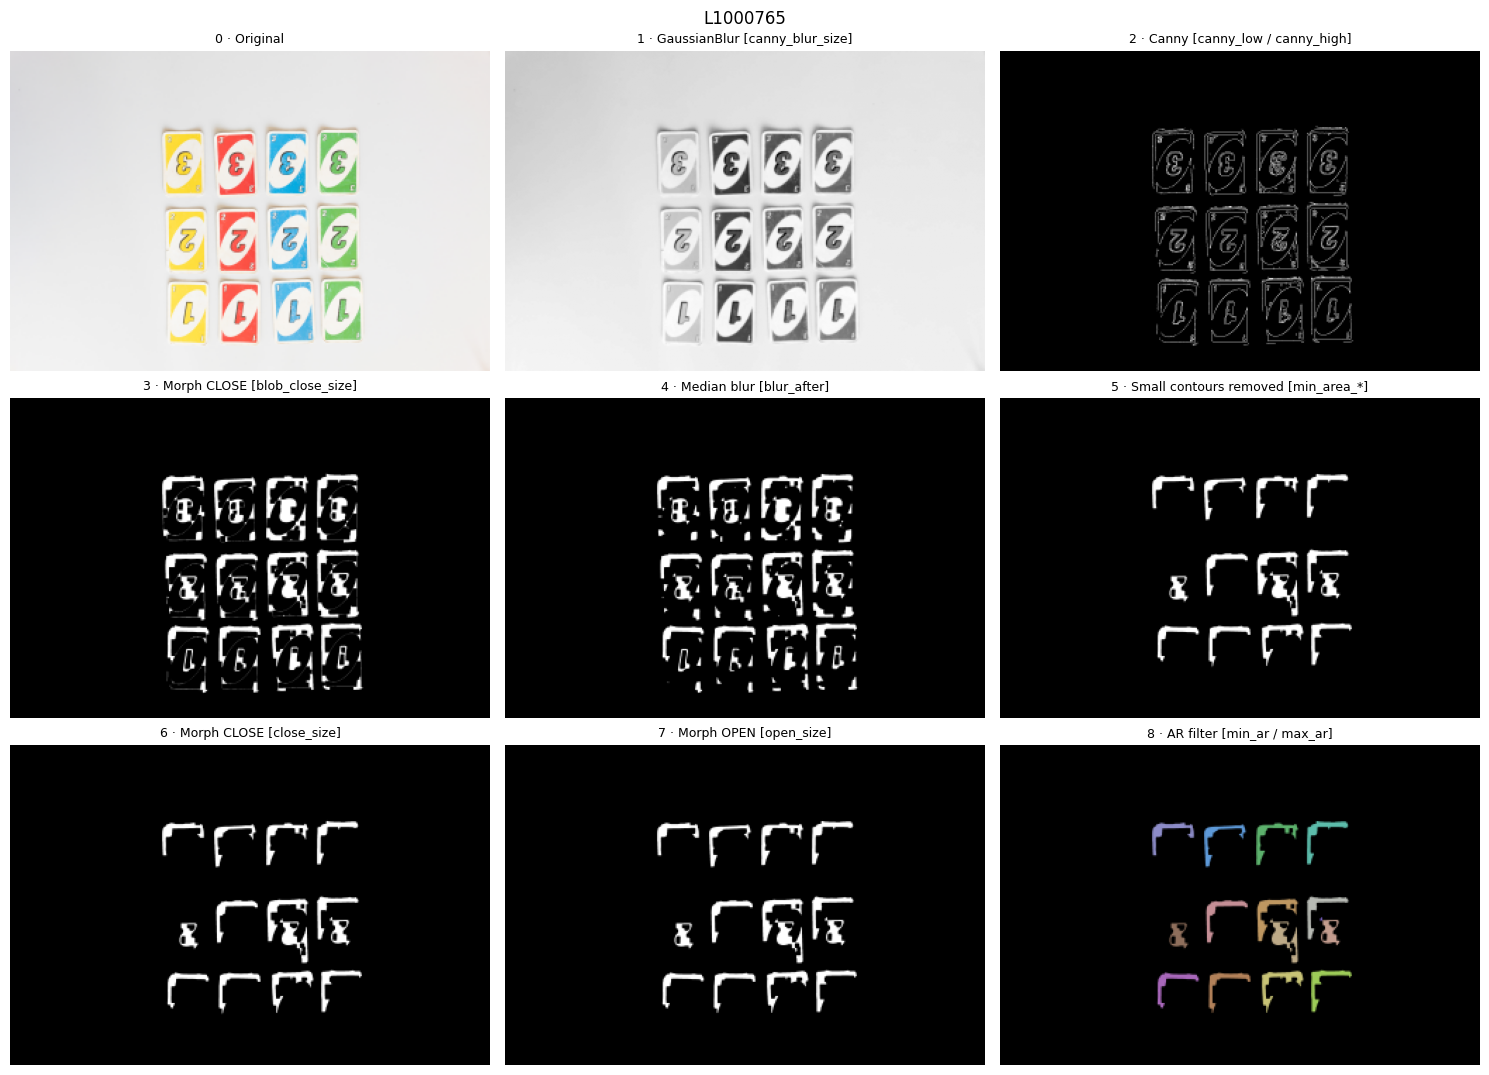

In [174]:
plot_pipeline_steps(color_rgb, pipeline_steps, preview_image_name)

In [175]:
selected = list(image_components.keys()) if images_to_process is None else images_to_process

results: dict[str, object] = {}
for name in selected:
    r = extract_reference_card_assets(
        image_name=name, num_components=image_components[name], **pipeline_kwargs
    )
    results[name] = r
    print(f"{name}: {len(r.components)} components, {len(r.masks)} masks, {len(r.crops)} crops")

L1000765: 12 components, 12 masks, 12 crops
L1000766: 12 components, 12 masks, 12 crops
L1000767: 14 components, 14 masks, 14 crops
L1000768: 16 components, 16 masks, 16 crops


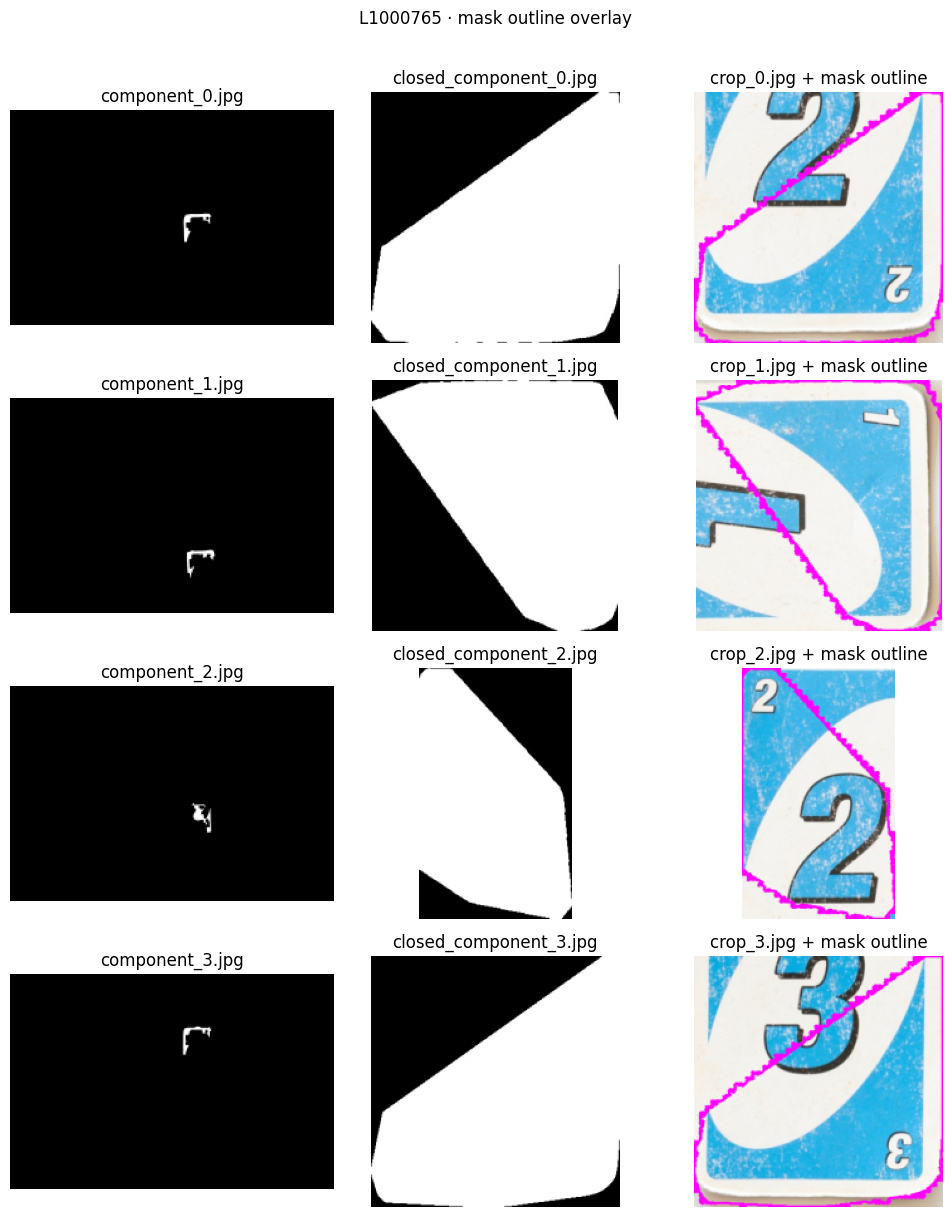

In [176]:
if preview_image_name not in results:
    raise KeyError(f"{preview_image_name!r} was not in images_to_process; add it or change preview_image_name.")

plot_crop_preview(results[preview_image_name], preview_image_name)